# QA Example

In this example we will show hot to perform a QA analysis with the acquired radiographs and autoradiograps available in the data/QA_images directory.

We begin with importing the required libraries

In [1]:
# python imports
import os

# external libraries
import matplotlib.pyplot as plt
import pandas as pd

# project libraries
from SPICA.tools.image_utils import OvoidsInfo, add_image
import SPICA.tools.utils as utils
from SPICA.tools.venezia_library import INCH
from SPICA.tools.venezia_library import coord_22libraries as coord_libraries
from SPICA.tools.venezia_library import coord_22holes as coord_holes
from SPICA.tools.venezia_library import path_markers as path_param


## 1. General parameters
Let's first define the parameters of the experiment. In this case, we basically need to define for which diameter we want to perform the QA.

In [2]:
_ovoid = 22
ovoids = OvoidsInfo(_ovoid)

Secondly, we load in memory the radiograph and autoradiograph files.

* Radiographs: since multiple are found, we will use the redundancy to compute the center of the ovoid. We load all images in the directory starting with rad*.*
* Autoradiographs: they should follow the naming convention CXPPYY*. We load all available images in the specified directory following this criteria.

In [4]:
# load radiographs and save them to MyImage object
_dir = os.path.join(os.getcwd(), '..', 'data','QA_images', 'radiographs')
_dir_files = os.listdir(_dir)
rad_imgs = []
for _f in _dir_files:
    rad_imgs = add_image(rad_imgs, os.path.join(_dir, _f), 'rad')
if len(rad_imgs) == 0:
    default_rad_22 = os.path.join(os.getcwd(), '..', 'data','default_rads', '22.jpg')
    rad_imgs = add_image([], default_rad_22, 'rad' )

_rad_rep = len(rad_imgs)
ovoids.num_rep = _rad_rep

# load autoradiographs and save them to MyImage object
_dir = os.path.join(os.getcwd(), '..', 'data', 'QA_images', 'autoradiographs')
_dir_files = os.listdir(_dir)
autorad_imgs = []
for _f in _dir_files:
    if (_f[0] == 'C') and (_f[2] == 'P'): #c
        autorad_imgs = add_image(autorad_imgs, os.path.join(_dir, _f), [int(_f[1]), int(_f[3:5])])
        

Lastly, we re-orient all images so that they all follow the same coordinate system established as reference.

In [5]:
# invert horizontally
for _k in rad_imgs + autorad_imgs:
    _k.image_invert()

# set the same resolution
res = utils.get_min_res(rad_imgs + autorad_imgs)
rad_imgs = utils.set_same_res(rad_imgs, res=res)
autorad_imgs = utils.set_same_res(autorad_imgs, res=res)

# convert coordinates expressed in milimeters to pixels
for _key in coord_holes.keys():
    coord_holes[_key][0] *= res / INCH
    coord_holes[_key][1] *= res / INCH
    coord_holes[_key][2] *= res / INCH
for _key in coord_libraries.keys():
    coord_libraries[_key][0] *= res / INCH
    coord_libraries[_key][1] *= res / INCH
    coord_libraries[_key][2] *= res / INCH

# trim the working area
_margin = int(res / INCH)  # 1 mm margin to avoid edges artifacts
_x, _y = utils.get_min_fov(rad_imgs + autorad_imgs)
for _k in rad_imgs + autorad_imgs:
    _k.image_trim([_x - _margin, _y - _margin])


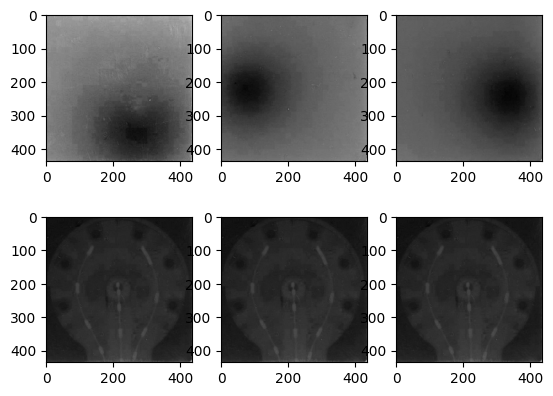

In [6]:
fig, ax = plt.subplots(2, 3)
ax[0, 0].imshow(autorad_imgs[0].img, cmap='gray')
ax[0, 1].imshow(autorad_imgs[1].img, cmap='gray')
ax[0, 2].imshow(autorad_imgs[2].img, cmap='gray')
for i in range(min(len(rad_imgs), 3)):
    ax[1, i].imshow(rad_imgs[0].img, cmap='gray')

plt.show()

## 2.Radiography processing

(A) We preprocess the radiography image(s) available using the function ```processRad(image, ovoids)```.
We compute the following:
* Smoothing filter for noise removal
* Computing background and holes segmentation
* Compute ovoid center as the centroid of all detected holes.

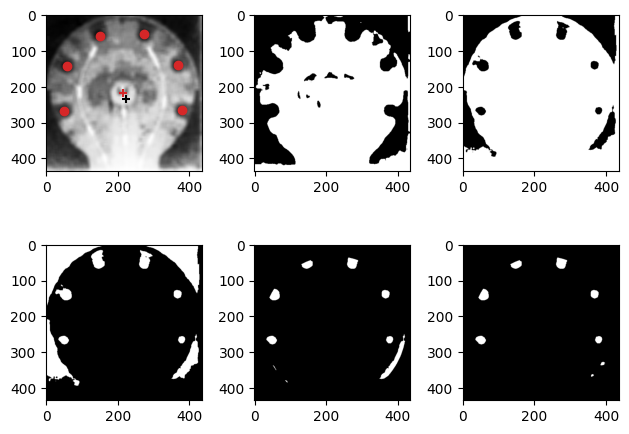

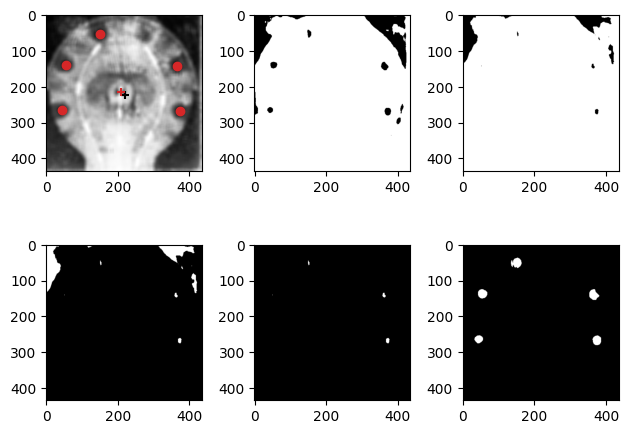

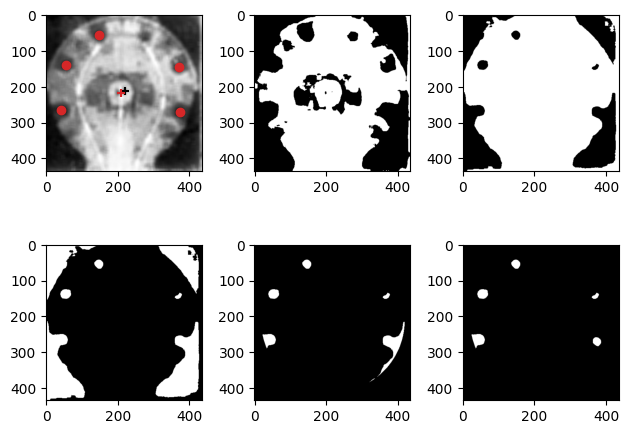

In [8]:
from src.tools.utils import *
import copy

rad_imgs_cp = copy.deepcopy(rad_imgs)

for it_img, img in enumerate(rad_imgs_cp):
    # pixel values normalization
    img.img = utils.normalization(img.img)
    # gradient filter application
    # imgs[_k].img = utils.normalization(imgs[_k].img*utils.gradient(imgs[_k].img))
    # radiograph processing
    rad_imgs[it_img] = utils.processRAD(img, ovoids, figures=True, eq_hist=True)
    # plt.show()
    


Let's see how our preprocessed images look like:

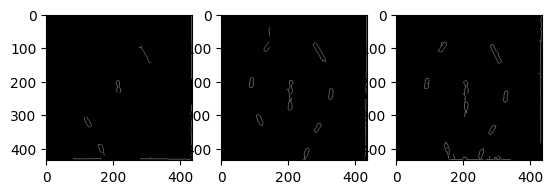

In [9]:
fig, ax = plt.subplots(1, 3)
for i in range(min(len(rad_imgs), 3)):
    ax[i].imshow(rad_imgs[i].processed_img, cmap='gray')
plt.show()

(B) Update ovoid center
* Exploit redundancy if there are multiple images available
* Add detected holes to each ovoid. It can have multiple detections for each hole if multiple images are provided.
* Use the difference between the theoretical and computed hole positions to update the center.

In [10]:
# ovoids centre calculation using the mean value of the radiographs' measures
_centres = []
for img in rad_imgs:
    _centres.append(img.centre)
ovoids.calc_mean_centre(_centres)

# centre correction by adjusting the theoretical holes to those detected
ovoids.reset_holes()  # reset for development purposes
for img in rad_imgs:
    for _ele in img.holes:
        ovoids.add_holes(_ele)


_diff = [0, 0]
_n = 0
for _k in coord_holes.keys(): # iterate over theoretical hole coordinates
    for _l in ovoids.holes.keys(): # iterate over detected holes
        diff = np.abs(_l - _k)
        if diff > 180:
            diff = 360 - diff
            
        if diff < ovoids.adj_holes / 2: # if the detected angle and the theoretical hole coincide, update the difference in coordinates.
            for _ele in ovoids.holes[_l]:
                _diff[0] += _ele[0] - coord_holes[_k][0]
                _diff[1] += _ele[1] - coord_holes[_k][1]
                _n += 1

_diff[0] /= _n
_diff[1] /= _n

ovoids.mean_centre[0] -= _diff[0]
ovoids.mean_centre[1] += _diff[1]

## 3. Autoradiography processing

The following steps are performed:
* Min-max normalization [0, 1].
* Use the contours of the image to compute the minimum "background" value.
* The foreground class is used to compute the centroid that will be used as the "source" point.

Let's see an example from the three first autoradiographs.


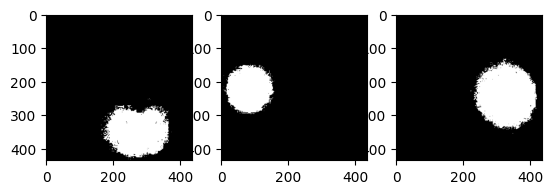

In [11]:
for it_img, img in enumerate(autorad_imgs):
    autorad_imgs[it_img] = utils.processAUTORAD(img)

fig, ax = plt.subplots(1, 3)
for i in range(min(len(rad_imgs), 3)):
    ax[i].imshow(autorad_imgs[i].processed_img, cmap='gray')
plt.show()

## 4. Results

Finally, we compute the results
* Use the equalized radiograph image as background image to show the source delineation.
* We compute and save all detected coordinates and the associated Type-A uncertainties for both right and left channels for all available positions. 
* We show the theoretical (green) and detected (red) source positions using a cross, '+'.
* We show the theoretical (green) and detected (red) ovoid holes using a circle, 'o'.


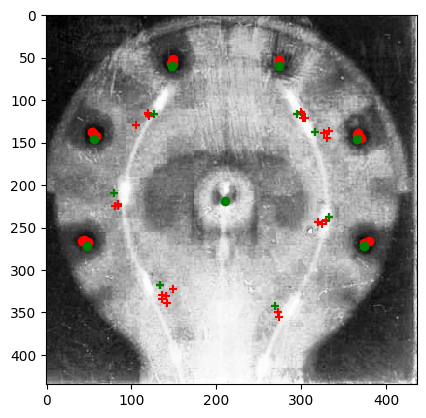

In [14]:
# background image to display the results
background = np.zeros([rad_imgs[0].y_size, rad_imgs[0].x_size])
for img in rad_imgs:
    background += image_histogram_equalization(img.img)
background /= ovoids.num_rep

# figure to show the results
plt.figure()

plt.imshow(background, cmap='gray')

_pos_dict = {'channel': [], 'distance': [], 'c_x': [], 'c_y': [], 'uA_x': [], 'uA_y': []}

for img in autorad_imgs:
    # data preparation
    _pos = [img.id[0], path_param['distal']] # [channel, distal distance]
    
    if (img.id[0] == 1): # right channel
        _pos[1] -= (img.id[1] - 1) * path_param['step'] # we remove the number of steps from the distal position. P01 == 0mm, P02 == step mm, etc.
        
    elif (img.id[0] == 2) & (img.id[1] == 2): # left channel and position 2
        _pos[1] -= path_param['step0'] # we remove the number of steps from the distal position. P01 == 0mm, P02 == step mm, etc.
        
    elif (img.id[0] == 2) & (img.id[1] > 2):  # left channel and position > 2
        _pos[1] -= (img.id[1] - 2) * path_param['step'] + path_param['step0']
        
    for _l in img.source:
        _pos.append(_l) # [channel, distal distance, centroid_x, centroid_y], for saving purposes only
        
    # changes the coordinates system
    _pos[2] -= ovoids.mean_centre[0] # remove the ovoid center (calculated from radiographies) from the centroid center
    _pos[3] -= ovoids.mean_centre[1] # remove the ovoid center (calculated from radiographies) from the centroid center
    _pos[3] = -_pos[3]
    
    # passes the coordinates in pixels to milimeters
    for _l in range(2, len(_pos)):
        _pos[_l] *= INCH / res

    # displays the positions of the source
    plt.scatter(img.source[0], img.source[1], marker='+', color='red')
    
    # displays only the libraries positions that have been studied
    plt.scatter(ovoids.mean_centre[0] + coord_libraries[tuple(_pos[0:2])][0],
                ovoids.mean_centre[1] - coord_libraries[tuple(_pos[0:2])][1], marker='+', color='green')
    
    # writes the data
    _pos_dict['channel'] += [_pos[0]]
    _pos_dict['distance'] += [_pos[1]]
    _pos_dict['c_x'] += [_pos[2]]
    _pos_dict['c_y'] += [_pos[3]]
    _pos_dict['uA_x'] += [_pos[4]]
    _pos_dict['uA_y'] += [_pos[5]]


_pos_df = pd.DataFrame(_pos_dict)
_pos_df.to_csv("coords" + str(ovoids.ovoid) + ".csv")

# displays the reference elements
for img in rad_imgs:
    # measured centres
    # plt.scatter(img.centre[0], img.centre[1], color='red')
    # measured holes
    plt.scatter([img.holes[_l][0] for _l in range(len(img.holes))],
                [img.holes[_l][1] for _l in range(len(img.holes))], color='red')
# mean centre
plt.scatter(ovoids.mean_centre[0], ovoids.mean_centre[1], color='green')
# theoretical holes
for _key in coord_holes.keys():
    plt.scatter(ovoids.mean_centre[0] + coord_holes[_key][0], ovoids.mean_centre[1] - coord_holes[_key][1], color='green')
